# 7. Canopy structure

Vertical profiles and plant area from a point cloud, and gap fraction from
pulse data. For the rigorous ray-traced version see notebook 9.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sylva
from sylva import synthetic

plt.rcParams.update({"figure.dpi": 90, "figure.figsize": (7, 4), "axes.grid": False})
from sylva import canopy, ground

cloud = ground.classify_ground_csf(synthetic.forest().without("classification"))
cloud = ground.normalize_height(cloud, ground.make_dtm(cloud, 0.5))

## Occupancy and the contact-frequency profile

`voxelize` counts points per voxel. `pad_profile_voxel` turns the fraction of occupied voxels per layer into plant area density (a simplified Hosoi & Omasa 2006, assuming vertical beams and G = 0.5). It ignores occlusion, which is why pulse data is better.

voxel grid (nx, ny, nz): (82, 83, 71)  PAI: 1.0


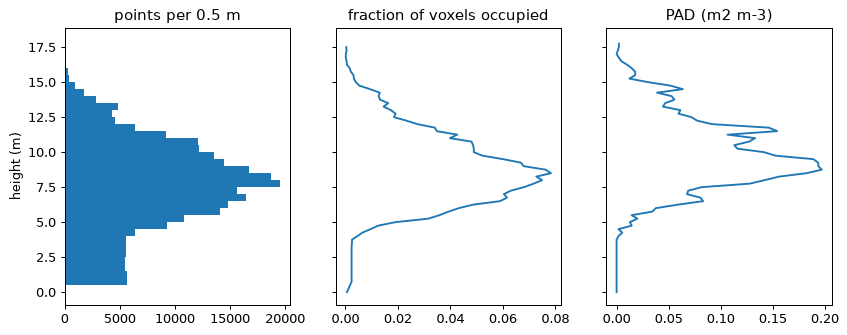

In [2]:
veg = cloud[cloud.attrs["height"] > 0.5]
grid = canopy.voxelize(veg, 0.25)
z, pad = canopy.pad_profile_voxel(veg, voxel_size=0.25)
print("voxel grid (nx, ny, nz):", grid.shape, " PAI:", round(float(np.sum(pad) * 0.25), 2))

hb, counts = canopy.vertical_profile(veg, bin_size=0.5)
fig, ax = plt.subplots(1, 3, figsize=(11, 4), sharey=True)
ax[0].barh(hb, counts, height=0.5, align="edge"); ax[0].set(title="points per 0.5 m", ylabel="height (m)")
ax[1].plot(grid.vertical_profile(), grid.z_levels() - grid.origin[2]); ax[1].set(title="fraction of voxels occupied")
ax[2].plot(pad, z); ax[2].set(title="PAD (m2 m-3)");

## Gap fraction from pulses

A scanner in the middle of the plot fires pulses on an angular grid
(`synthetic.scan`; with RIEGL data use `ScanPosition.read_shots`). A pulse with no
echo above `min_height` is a gap. `lai_from_gap_fraction` inverts P(θ) by the
hinge angle (57.5°) or Miller's integral.

Shots(n_shots=748,800, n_echoes=78,034) - 91% of pulses returned nothing
true leaf area index of the scene: 0.30 (plus bark)


effective PAI (hinge): 0.12
effective PAI (miller): 0.13


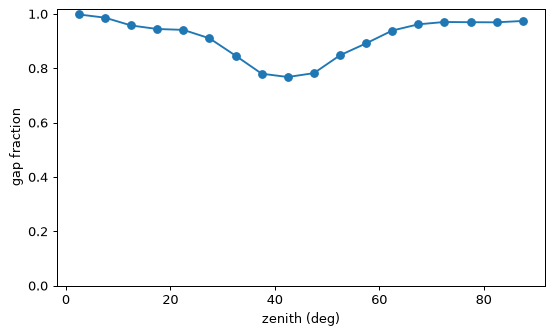

In [3]:
shots = synthetic.scan(synthetic.forest(), origin=(10.0, 10.0, 1.5), resolution_deg=0.25)
print(shots, f"- {np.mean(shots.echo_count == 0):.0%} of pulses returned nothing")
print(f"true leaf area index of the scene: {synthetic.leaf_area(synthetic.forest()) / 20**2:.2f} (plus bark)")
echo_height = shots.echo_xyz()[:, 2] - synthetic.terrain_height(*shots.echo_xyz()[:, :2].T)
zen, gap = canopy.gap_fraction_zenith(shots, echo_height, min_height=1.0, zenith_edges=np.arange(0, 95, 5.0))
for method in ("hinge", "miller"):
    print(f"effective PAI ({method}): {canopy.lai_from_gap_fraction(zen, gap, method):.2f}")
plt.plot(zen, gap, "o-"); plt.gca().set(xlabel="zenith (deg)", ylabel="gap fraction", ylim=(0, 1.02));